In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from urllib.parse import quote_plus

server = "localhost"
database = "weather_db"

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

params = quote_plus(connection_string)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

query = """
SELECT *
FROM weather_summary
"""

df = pd.read_sql(query, engine)

df["year"] = pd.to_numeric(df["year"])
df["month"] = pd.to_numeric(df["month"])
df["avg_value"] = pd.to_numeric(df["avg_value"])

print(df.shape)
df.head()

(1782, 7)


,element,year,month,avg_value,max_value,min_value,record_count
0,TMIN,2010,9,11.320582,51.7,-78.4,474043
1,TMIN,2010,2,-2.505543,51.1,-99.0,443194
2,PRCP,2010,9,31.843224,4808.0,0.0,900694
3,TMIN,2010,10,6.667776,2991.3,-99.0,486707
4,TMIN,2010,1,-3.312572,58.9,-73.3,487928


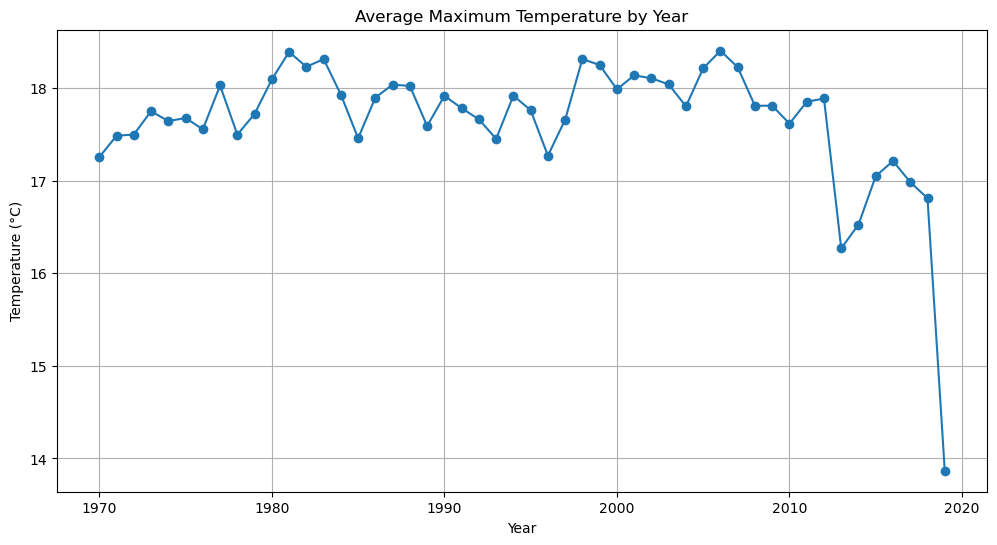

In [19]:
tmax = df[df["element"] == "TMAX"]

yearly = tmax.groupby("year")["avg_value"].mean().sort_index()

plt.figure(figsize=(12,6))
plt.plot(yearly.index, yearly.values, marker="o")
plt.title("Average Maximum Temperature by Year")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

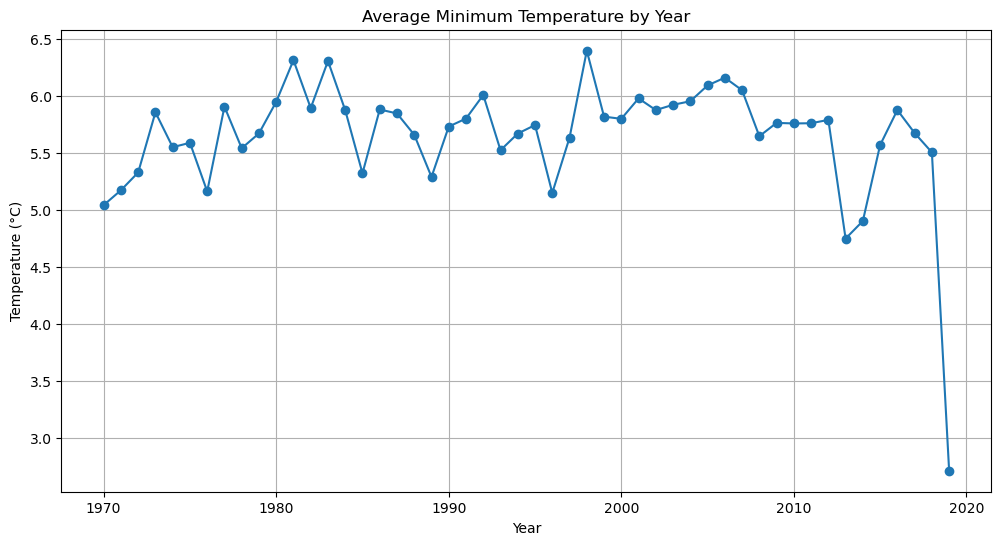

In [20]:
tmin = df[df["element"] == "TMIN"]

yearly = tmin.groupby("year")["avg_value"].mean().sort_index()

plt.figure(figsize=(12,6))
plt.plot(yearly.index, yearly.values, marker="o")
plt.title("Average Minimum Temperature by Year")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

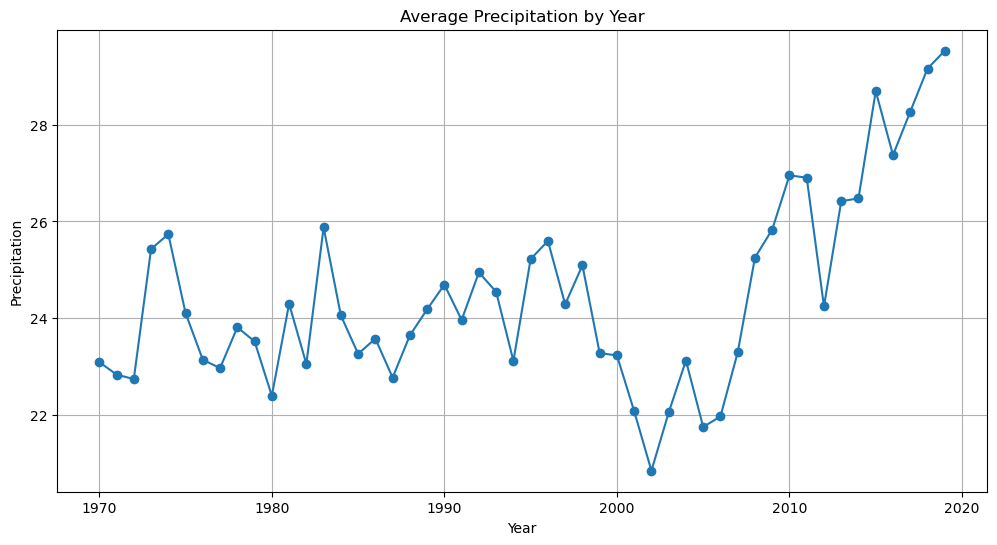

In [21]:
prcp = df[df["element"] == "PRCP"]

yearly = prcp.groupby("year")["avg_value"].mean().sort_index()

plt.figure(figsize=(12,6))
plt.plot(yearly.index, yearly.values, marker="o")
plt.title("Average Precipitation by Year")
plt.xlabel("Year")
plt.ylabel("Precipitation")
plt.grid()
plt.show()

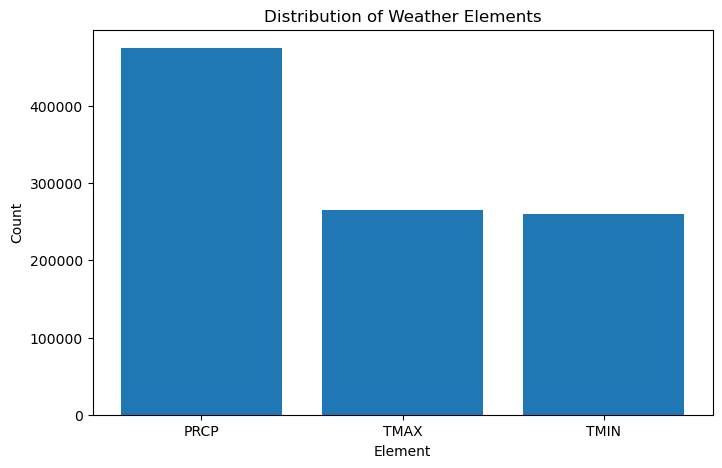

In [10]:
element_count = df["element"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    element_count.index,
    element_count.values
)

plt.title(
    "Distribution of Weather Elements"
)

plt.xlabel("Element")
plt.ylabel("Count")

plt.show()

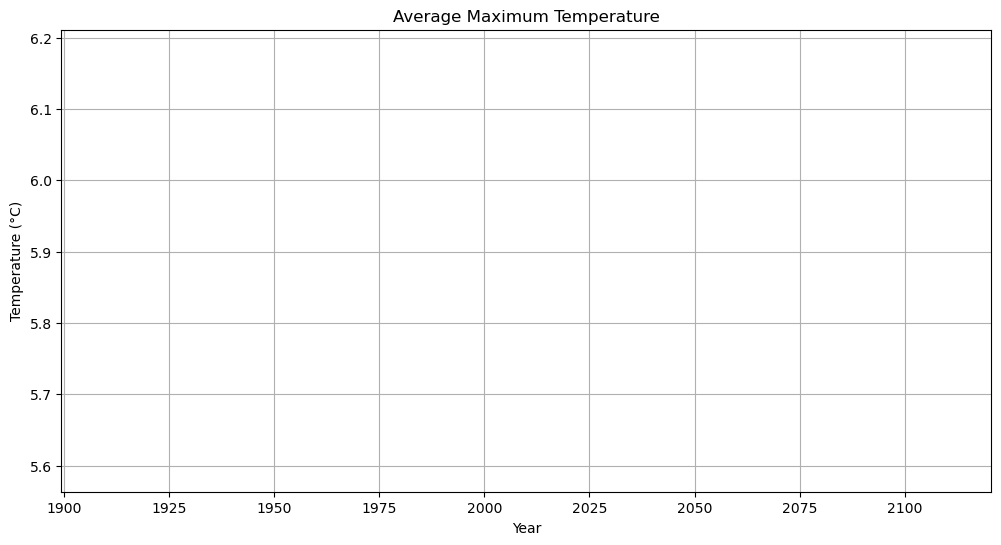

In [11]:
tmax = df[
    df["element"]=="TMAX"
]

yearly = (
    tmax.groupby("year")["value"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    yearly.index,
    yearly.values
)

plt.title(
    "Average Maximum Temperature"
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

plt.grid()

plt.show()

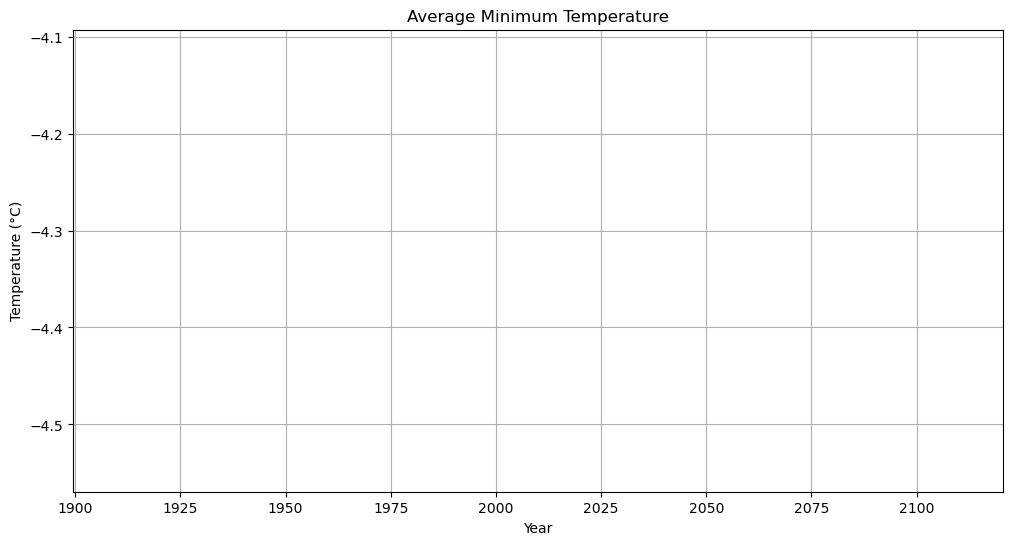

In [12]:
tmin = df[
    df["element"]=="TMIN"
]

yearly = (
    tmin.groupby("year")["value"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    yearly.index,
    yearly.values
)

plt.title(
    "Average Minimum Temperature"
)

plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

plt.grid()

plt.show()

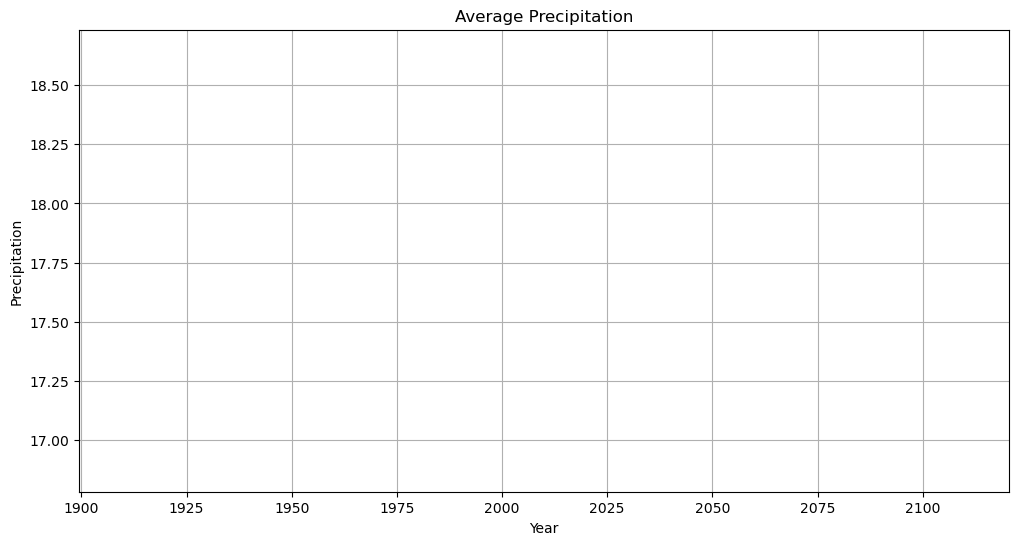

In [13]:
prcp = df[
    df["element"]=="PRCP"
]

yearly = (
    prcp.groupby("year")["value"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    yearly.index,
    yearly.values
)

plt.title(
    "Average Precipitation"
)

plt.xlabel("Year")
plt.ylabel("Precipitation")

plt.grid()

plt.show()